# Hypothesis Testing

- EDA
    + Summary
    + Visualization
- Hypothesis testing

In [2]:
50 / 6

[1] 8.333333

In [6]:
8  + 6 + 9 + 9 + 9 + 9


[1] 50

In [7]:
6 + 6 + 5 + 7 + 7 + 6

[1] 37

In [ ]:
1.8, 1.7

$H_0$ = Null Hypothesis

$H_1$ or $H_A$ = Alternate/alternative hypothesis

In [8]:
snd = rnorm(10000, 0, 1)

In [14]:
dist = list(snd=snd) |> as.data.frame() |> tibble()

In [10]:
require(tidyverse)

Loading required package: tidyverse
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
In geom_density(method = lm, bw = 1) :
  Ignoring unknown parameters: `method`


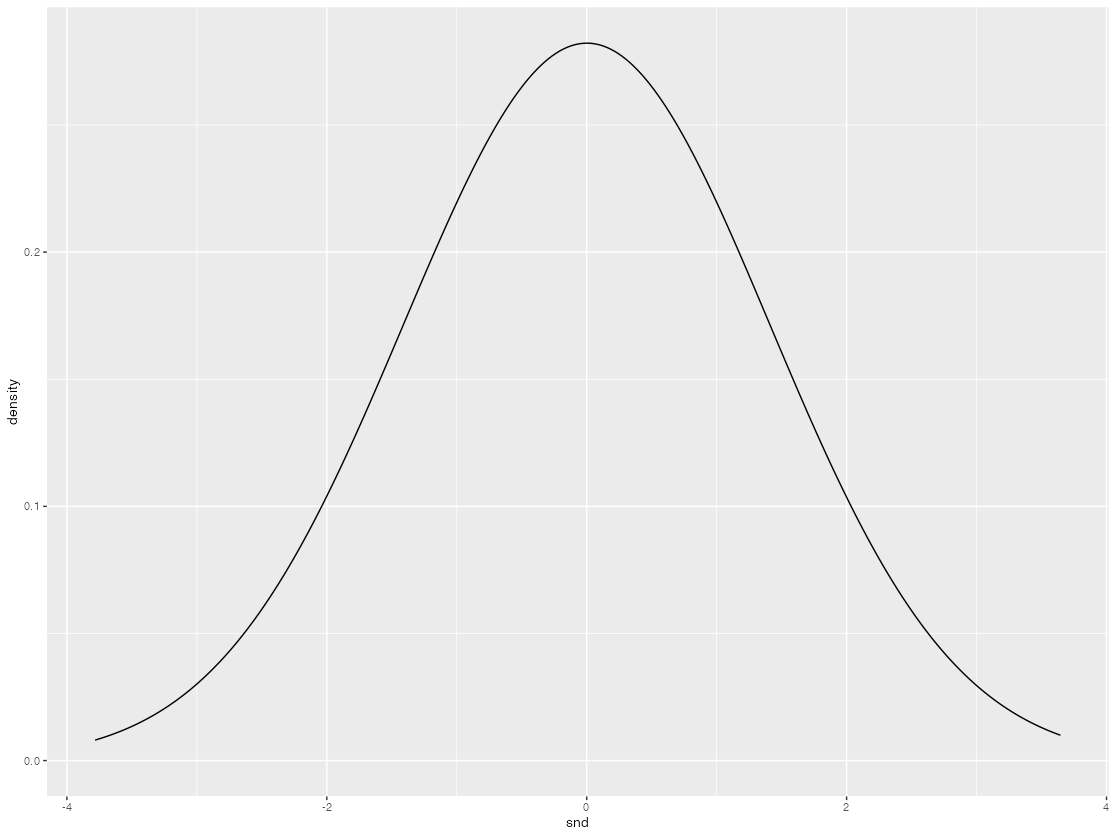

In [20]:
dist |> ggplot() + aes(snd) + geom_density(method=lm, bw=1)

In [21]:
nhanes <-  read_csv("data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome, HomeOwn, Work, BMICatUnder20yrs, BMI_WHO, Diabetes, HealthGen, LittleInterest, Depre...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Length, HeadCirc, Height, BMI, Pulse, BPSysAve, BPDiaAve, BPSys1, BPDia1, BPSys2, BPDia2, B...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [35]:
nhanes |> filter(Age < 18) |> with(cor.test(Age, Height)) 


	Pearson's product-moment correlation

data:  Age and Height
t = 246.88, df = 6203, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9503409 0.9549404
sample estimates:
      cor 
0.9526951 


In [29]:
a <- c(1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 1, 2, 3, 4)
b <- c(1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7)

In [30]:
cor(a, b)

[1] 0.6933752

In [31]:
cor.test(a, b)


	Pearson's product-moment correlation

data:  a and b
t = 3.3333, df = 12, p-value = 0.005961
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2575437 0.8947753
sample estimates:
      cor 
0.6933752 


Warning message:
Removed 2258 rows containing non-finite outside the scale range (`stat_bin()`). 


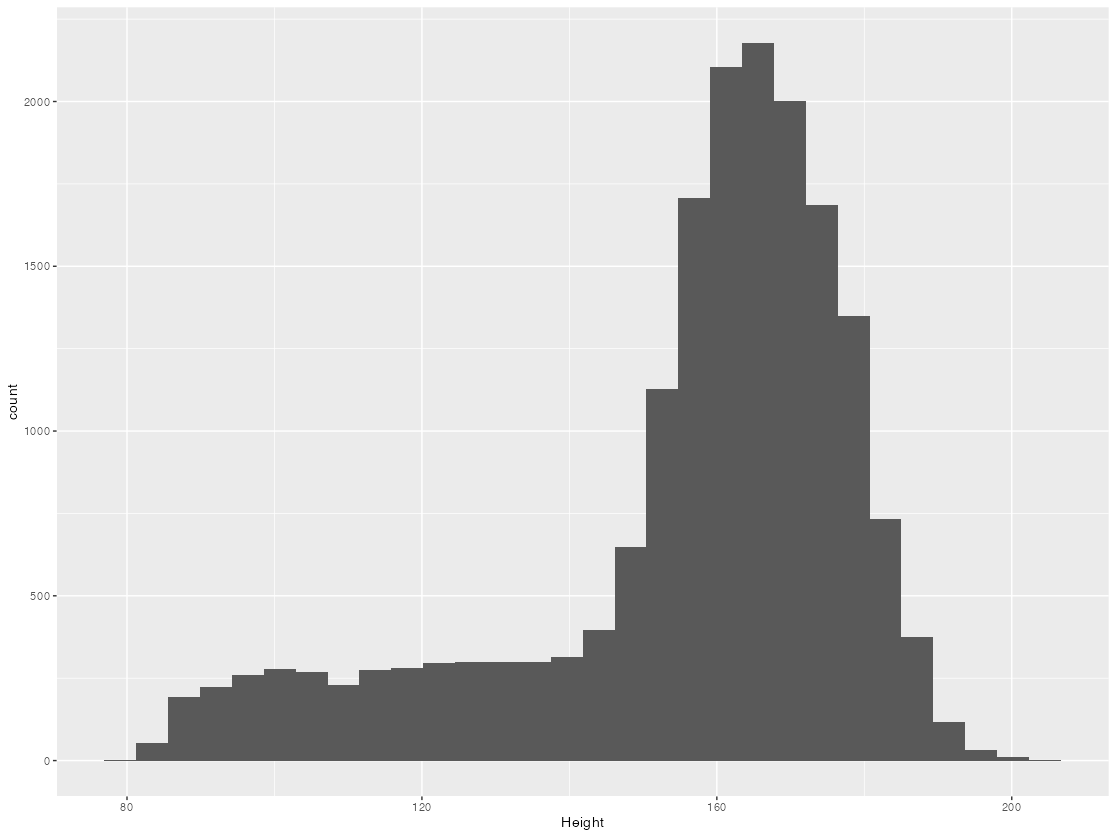

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.

In [36]:
nhanes |> ggplot() + aes(Height) + geom_histogram() 

In [39]:
nhanes |> with(t.test(Height ~ Gender))


	Welch Two Sample t-test

data:  Height by Gender
t = -26.929, df = 17172, p-value < 2.2e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -9.969432 -8.616575
sample estimates:
mean in group female   mean in group male 
            151.3393             160.6323 


In [46]:
height_men <- c(1.8, 1.8, 1.81, 1.78, 1.79, 1.8, 1.8, 1.81, 1.78, 1.79)
height_women <- c(1.8, 1.78, 1.77, 1.6, 1.65, 1.8, 1.78, 1.77, 1.6, 1.65)

In [47]:
t.test(height_men, height_women)


	Welch Two Sample t-test

data:  height_men and height_women
t = 2.8359, df = 9.2943, p-value = 0.01894
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 0.01566627 0.13633373
sample estimates:
mean of x mean of y 
    1.796     1.720 


In [48]:
wilcox.test(height_men, height_women)

Warning message:
In wilcox.test.default(height_men, height_women) :
  cannot compute exact p-value with ties



	Wilcoxon rank sum test with continuity correction

data:  height_men and height_women
W = 86, p-value = 0.006229
alternative hypothesis: true location shift is not equal to 0


In [50]:
nhanes |> with(aov(Height ~ Race1)) |> summary()

               Df  Sum Sq Mean Sq F value Pr(>F)    
Race1           4  347770   86943   161.4 <2e-16 ***
Residuals   18030 9710745     539                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2258 observations deleted due to missingness

In [51]:
nhanes |> with(kruskal.test(Height ~ Race1))


	Kruskal-Wallis rank sum test

data:  Height by Race1
Kruskal-Wallis chi-squared = 1003.5, df = 4, p-value < 2.2e-16


In [52]:
nhanes |> with(chisq.test(table(Race1, Education)))


	Pearson's Chi-squared test

data:  table(Race1, Education)
X-squared = 2227.4, df = 16, p-value < 2.2e-16


In [66]:
nhanes |> select(Race1, Education) |> table() 

          Education
Race1      8th Grade 9 - 11th Grade College Grad High School Some College
  Black          124            483          414         688          864
  Hispanic       248            216          186         237          320
  Mexican        618            329          116         308          305
  Other          118            105          552         189          327
  White          213            654         1388        1173         1583

In [67]:
((nhanes |> select(Race1, Education) |> table()  |> chisq.test())$expected) |> round() 

          Education
Race1      8th Grade 9 - 11th Grade College Grad High School Some College
  Black          289            391          581         568          744
  Hispanic       136            183          273         266          349
  Mexican        188            255          379         370          484
  Other          145            196          292         285          373
  White          563            762         1132        1106         1449

|Var1|Var2|Normality|Test|
|-|-|-|-|
|Num|Num|Yes/No|corelation test|
|Num|Bin|Yes|T test|
|Num|Bin|No|Wilcoxon test|
|Num|Cat|Yes|Anova|
|Num|Cat|No|Kruskal Wallis test|
|Cat|Cat|--|Chisq test|

In [68]:
require(gtsummary)

Loading required package: gtsummary


In [71]:
nhanes |> 
  select(Age, Height, Weight, Gender, Race1, Education, Diabetes) |> 
  tbl_summary(missing='no', digits=c(all_categorical() ~ c(0, 1)))

Characteristic,"N = 20,2931"
Age,"28 (10, 53)"
Height,"162 (150, 172)"
Weight,"66 (38, 84)"
Gender,
female,"10,212 (50.3%)"
male,"10,081 (49.7%)"
Race1,
Black,"4,640 (22.9%)"
Hispanic,"2,209 (10.9%)"
Mexican,"3,739 (18.4%)"


In [73]:
nhanes |> 
  select(Age, Height, Weight, Gender, Race1, Education, Diabetes) |> 
  tbl_summary(
    by = Diabetes,
    missing='no', 
    digits=c(all_categorical() ~ c(0, 1))
  ) |> add_p()

833 missing rows in the "Diabetes" column have been removed.


Characteristic,"No N = 17,7541","Yes N = 1,7061",p-value2
Age,"25 (10, 49)","62 (52, 72)",<0.001
Height,"162 (148, 171)","166 (158, 173)",<0.001
Weight,"65 (40, 82)","86 (73, 101)",<0.001
Gender,,,0.5
female,"8,940 (50.4%)",845 (49.5%),
male,"8,814 (49.6%)",861 (50.5%),
Race1,,,<0.001
Black,"3,980 (22.4%)",501 (29.4%),
Hispanic,"1,924 (10.8%)",181 (10.6%),
Mexican,"3,238 (18.2%)",264 (15.5%),
